MOIRE


 El efecto Moiré aparece cuando la frecuencia de muestreo es insuficiente para capturar las frecuencias espaciales altas (detalles muy finos y repetitivos) de la imagen original.

Si la frecuencia del patrón de la imagen supera la mitad de la frecuencia de muestreo (el límite de Nyquist), esa información "rebota" y se manifiesta como una frecuencia más baja y falsa.

Resultado: El sensor "ve" ondas o patrones curvos que no existen en la realidad.

2. Causas Principales en PDI
Submuestreo (Downsampling): Al reducir el tamaño de una imagen que contiene texturas finas (como una rejilla o tela) sin aplicar un filtro previo, los píxeles eliminados dejan "huecos" que deforman el patrón original.

Escaneo de Imágenes Impresas: Las imágenes impresas ya tienen una trama de puntos (semitonos). Al escanearlas, el sensor de la cámara o escáner (una rejilla de píxeles) se superpone a la trama de impresión, generando la interferencia.

Interpolación de Color (Demosaicing): En sensores con filtro Bayer, si el patrón de color es muy fino, el algoritmo de reconstrucción de color puede fallar y generar artefactos de color conocidos como "falsos colores de Moiré".

3. Cómo Mitigarlo en Procesamiento
Si estás trabajando con OpenCV o librerías similares, existen tres enfoques principales para manejarlo:

Filtro Anti-aliasing (Pre-procesamiento): Antes de reducir el tamaño de una imagen, se aplica un filtro de paso bajo (como un Blur Gaussiano). Esto elimina las frecuencias muy altas que el nuevo tamaño no podrá representar, evitando que se conviertan en Moiré.

Transformada de Fourier (Dominio de la Frecuencia): El efecto Moiré se identifica fácilmente en el espectro de potencia como picos de energía en frecuencias específicas fuera del origen. Se pueden aplicar filtros de muesca (Notch Filters) para eliminar esos picos y luego volver al dominio espacial.

Aumento de la Resolución de Muestreo: Capturar la imagen a una resolución mucho mayor para que el límite de Nyquist esté muy por encima de los detalles del patrón observado.

4. El Moiré como Herramienta
No siempre es un error. En metrología y análisis de deformaciones, se utiliza intencionalmente para medir desplazamientos microscópicos. Al superponer una rejilla de referencia sobre una superficie deformada, el patrón de Moiré resultante amplifica visualmente las deformaciones, permitiendo su anásis

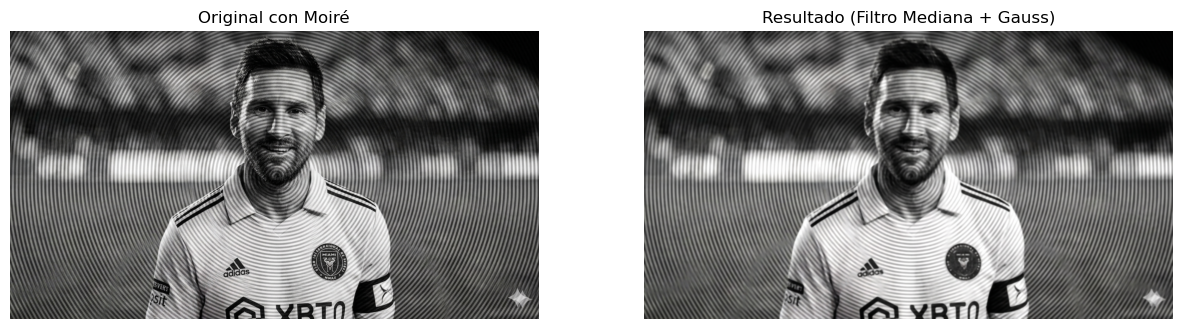

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen
# Reemplaza 'messi_moire.jpg' por la ruta de tu archivo
img = cv2.imread(r'D:\UNIVALLE\PDY\unidad 1\clases\img\messi_moire.png', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Aplicar Filtro de Mediana
# El kernel de 5 es ideal: elimina las líneas delgadas pero mantiene la forma de la cara
img_median = cv2.medianBlur(img_rgb, 5)

# 3. Aplicar un ligero desenfoque Gaussiano
# Esto ayuda a quitar los restos de las "ondas" que deja la mediana
img_final = cv2.GaussianBlur(img_median, (5, 5), 0)

# 4. (Opcional) Aumentar un poco el contraste para recuperar nitidez
# Multiplicamos por un factor ligeramente superior a 1
img_final = cv2.convertScaleAbs(img_final, alpha=1.1, beta=0)

# Visualización de resultados
plt.figure(figsize=(15, 7))

plt.subplot(121)
plt.title("Original con Moiré")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(122)
plt.title("Resultado (Filtro Mediana + Gauss)")
plt.imshow(img_final)
plt.axis('off')

plt.show()

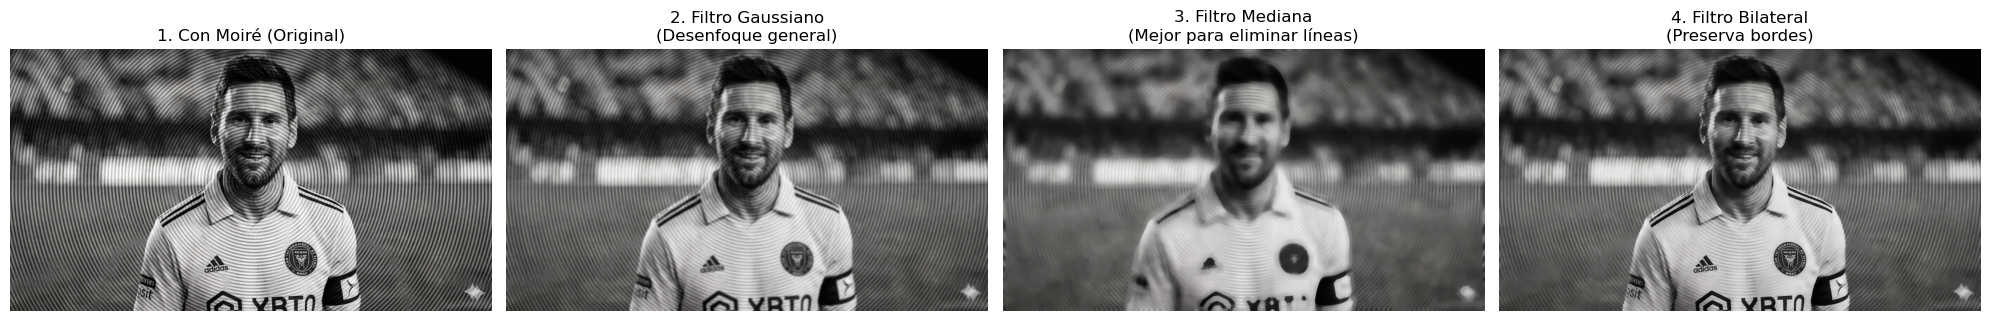

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de la ruta y carga de imagen
# Usamos 'r' para evitar problemas con las barras de Windows
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\messi_moire.png'
img = cv2.imread(ruta)

if img is None:
    print("Error: No se encontró la imagen. Revisa la ruta.")
else:
    # Convertimos a RGB para que Matplotlib muestre los colores correctamente
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- APLICACIÓN DE FILTROS (Ajustados para Moiré fuerte) ---

    # A. Filtro Gaussiano: Suavizado estándar
    # Usamos un kernel de 11 para que sea efectivo
    limpia_suave = cv2.GaussianBlur(img_rgb, (11, 11), 0)

    # B. Filtro de Mediana: El más potente contra patrones de líneas
    # Nota: El tamaño (21) debe ser impar. Es el que mejor borrará las ondas.
    limpia_mediana = cv2.medianBlur(img_rgb, 21)

    # C. Filtro Bilateral: Suaviza pero intenta mantener los bordes de la cara
    # d=15 (diámetro), sigmaColor=150, sigmaSpace=150
    limpia_bilateral = cv2.bilateralFilter(img_rgb, 15, 150, 150)

    # --- VISUALIZACIÓN ---

    plt.figure(figsize=(20, 10))

    # Original
    plt.subplot(141)
    plt.imshow(img_rgb)
    plt.title('1. Con Moiré (Original)')
    plt.axis('off')

    # Gaussiano
    plt.subplot(142)
    plt.imshow(limpia_suave)
    plt.title('2. Filtro Gaussiano\n(Desenfoque general)')
    plt.axis('off')

    # Mediana
    plt.subplot(143)
    plt.imshow(limpia_mediana)
    plt.title('3. Filtro Mediana\n(Mejor para eliminar líneas)')
    plt.axis('off')

    # Bilateral
    plt.subplot(144)
    plt.imshow(limpia_bilateral)
    plt.title('4. Filtro Bilateral\n(Preserva bordes)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

moire 


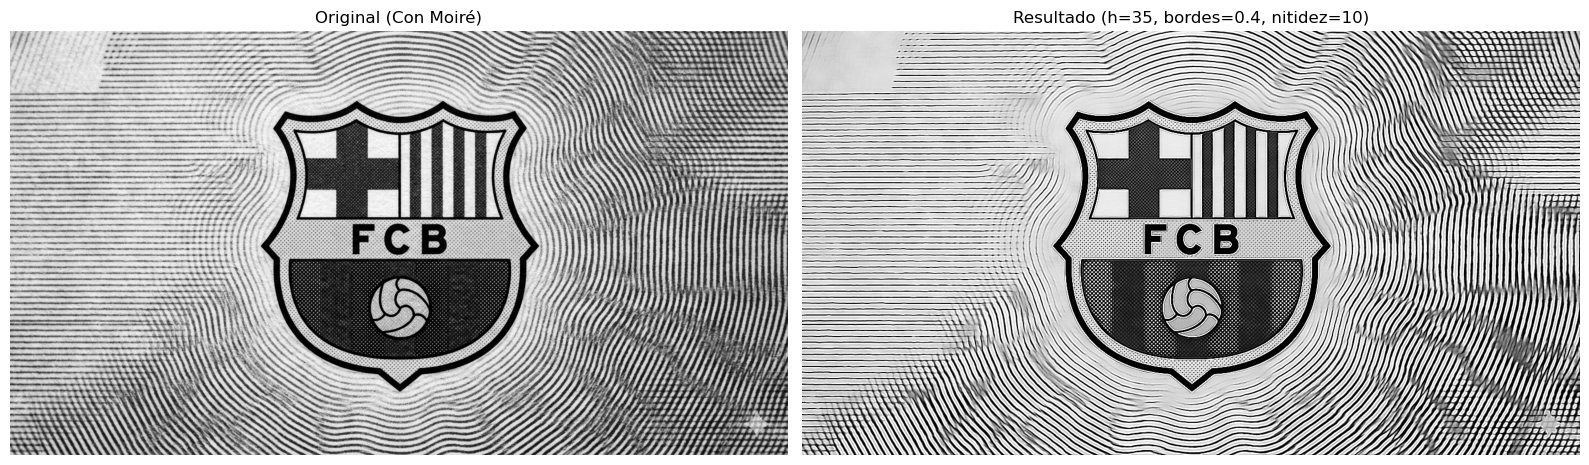

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def limpiar_moire_avanzado(ruta_img, h_limpieza=50, potencia_bordes=0.5, nitidez=11):
    """
    Función para eliminar moiré y ajustar nitidez.
    
    Parámetros:
    - h_limpieza: (10-50) Fuerza para borrar las líneas. Más alto = más limpieza.
    - potencia_bordes: (0.1-1.0) Cuánto rescatamos los bordes del escudo.
    - nitidez: (5-11) Qué tan marcadas queremos las letras y el balón.
    """
    # 1. Cargar imagen
    img = cv2.imread(ruta_img)
    if img is None:
        return "Error: No se encontró la imagen."

    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Eliminar el patrón de líneas (Denoising No Local)
    # Es el paso clave para que desaparezcan las líneas de la marca de agua
    denoised = cv2.fastNlMeansDenoising(gray, None, h=h_limpieza, 
                                        templateWindowSize=7, 
                                        searchWindowSize=21)

    # 3. Extraer gradiente (bordes puros) para no perder el escudo
    kernel_grad = np.ones((3,3), np.uint8)
    gradient = cv2.morphologyEx(denoised, cv2.MORPH_GRADIENT, kernel_grad)
    
    # Combinar la imagen limpia con sus bordes resaltados
    sharp_base = cv2.addWeighted(denoised, 1.0, gradient, potencia_bordes, 0)

    # 4. Aplicar kernel de nitidez (Sharpening)
    # El valor central define la fuerza de los bordes
    centro = nitidez
    laterales = -(centro - 1) / 8
    kernel_sharpen = np.array([[laterales, laterales, laterales], 
                               [laterales, centro,    laterales], 
                               [laterales, laterales, laterales]])
    
    resultado = cv2.filter2D(sharp_base, -1, kernel_sharpen)

    # Mostrar comparativa
    plt.figure(figsize=(16, 8))
    plt.subplot(121)
    plt.imshow(gray, cmap='gray')
    plt.title('Original (Con Moiré)')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(resultado, cmap='gray')
    plt.title(f'Resultado (h={h_limpieza}, bordes={potencia_bordes}, nitidez={nitidez})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- AQUÍ PUEDES JUGAR CON LOS VALORES ---
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\Barsa.png'

limpiar_moire_avanzado(
    ruta, 
    h_limpieza=35,      # Sube esto si aún ves líneas de fondo
    potencia_bordes=0.4, # Ajusta qué tan "negro" se ve el contorno del escudo
    nitidez=10          # Sube esto para que el texto FCB resalte más
)

ALISING 

1. El Filtro Gaussiano y la Atenuación de FrecuenciasEl filtro Gaussiano es un operador de suavizado lineal que actúa como un filtro de paso bajo en el dominio de la frecuencia. Matemáticamente, la función Gaussiana en dos dimensiones se define  En tu código, al usar un kernel de $5 \times 5$, estás definiendo el área de influencia de cada píxel. La importancia teórica aquí es que la distribución de pesos es mayor en el centro y disminuye hacia los bordes del kernel, lo que evita que aparezcan los "anillos" o artefactos de Gibbs que suelen dejar otros filtros lineales (como el de caja). Es la herramienta principal para reducir el aliasing porque reduce el ancho de banda de la imagen antes de que el ojo o el sensor detecten bordes dentados.
2. El Filtro de Mediana: Robustez No LinealA diferencia de los filtros basados en promedios, el filtro de mediana es un operador de orden estadístico. Su funcionamiento consiste en recorrer la imagen, tomar todos los valores de intensidad dentro de la ventana de $5 \times 5$, ordenarlos de menor a mayor y seleccionar el valor central (la mediana).Desde la perspectiva de PDI, este filtro es fundamental porque no genera nuevos valores de intensidad (no inventa colores); simplemente utiliza los existentes. En casos de aliasing severo o ruido impulsivo (sal y pimienta), la mediana es superior al Gaussiano porque puede eliminar por completo un píxel que sea radicalmente distinto a sus vecinos sin promediar su error con el resto de la imagen.
3. Filtro Bilateral: El Concepto de Fotometría y ProximidadEste es un filtro no lineal y preservador de bordes. Mientras que los filtros convencionales solo consideran la distancia espacial (qué tan lejos está un píxel de otro), el filtro bilateral añade una dimensión: la diferencia de intensidad o "dominio de rango".La teoría establece que el peso de un píxel vecino depende de dos Gaussianas:G_s (Espacial): Disminuye el peso según la distancia física.G_r (Rango): Disminuye el peso si la diferencia de color es muy alta.Esto explica por qué en tu código, al ajustar los parámetros a 75, 75, logras que el algoritmo "entienda" dónde termina un objeto y empieza el fondo. Si la diferencia de intensidad es mayor a ese umbral, el filtro deja de suavizar, protegiendo los bordes del difuminado típico de los otros filtros.
4. Post-procesamiento y Refinamiento OrgánicoTu implementación "Premium" aplica una técnica de cascada de filtrado. La razón teórica de aplicar un GaussianBlur ligero (kernel $3 \times 3$) después de un medianBlur reside en la textura final de la imagen.El filtro de mediana, aunque excelente eliminando el aliasing, tiende a crear un efecto de "parches" o áreas con colores demasiado planos y bordes algo artificiales (efecto de posterización). Al aplicar un pequeño desenfoque Gaussiano final, realizas una interpolación suave de esas áreas planas. Esto restaura la apariencia orgánica de la imagen, simulando mejor la forma en que el ojo humano percibe las transiciones de luz, logrando un antialiasing visualmente más profesional.
5. Conexión con el Dominio de la Frecuencia (Transformada de Fourier)Para cerrar la teoría, es vital mencionar que todo el aliasing que ves en la imagen original son réplicas del espectro que se han solapado. Al aplicar estos filtros en tu código, estás realizando una operación de convolución en el dominio espacial que equivale a una multiplicación en el dominio de la frecuencia.Lo que estás haciendo técnicamente es "limpiar" el espectro de potencia de la imagen, eliminando las altas frecuencias que causan la interferencia y permitiendo que solo las frecuencias fundamentales (la estructura del objeto) permanezcan claras.

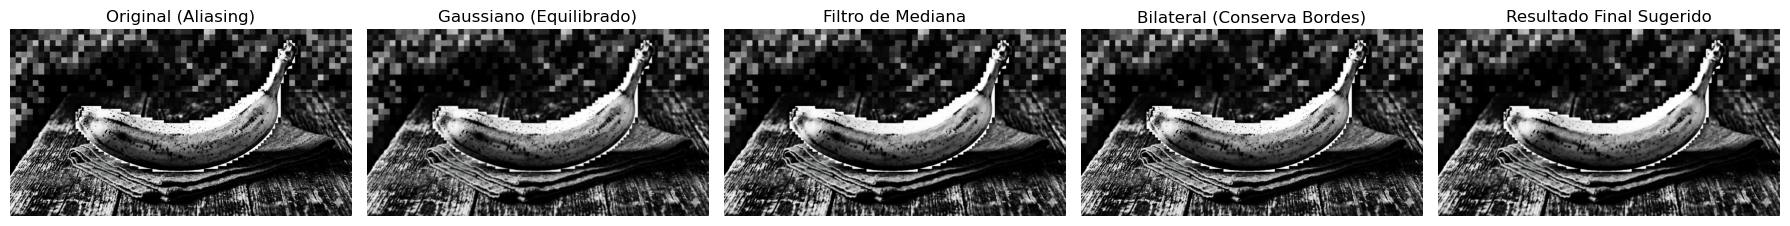

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\ElPlatano.png'
img = cv2.imread(ruta)

# 1. Filtro Gaussiano Refinado: Un kernel de (5,5) suele ser el "punto dulce"
# para suavizar bordes sin perder la identidad del objeto.
limpia_gauss = cv2.GaussianBlur(img, (5, 5), 1.5)

# 2. Filtro de Mediana: Muy efectivo para el aliasing tipo "pixelado"
# Reemplaza cada píxel con la mediana de los píxeles circundantes.
limpia_mediana = cv2.medianBlur(img, 5)

# 3. Filtro Bilateral Ajustado: Reducimos el diámetro pero aumentamos 
# el sigma del color para que suavice más el degradado manteniendo bordes.
limpia_bilateral = cv2.bilateralFilter(img, 9, 70, 70)

# 4. Combinación (Opcional): Un toque de desenfoque sobre la mediana
# para un acabado más orgánico ("Antialiasing Premium")
limpia_premium = cv2.GaussianBlur(limpia_mediana, (3, 3), 0)

# Visualización
plt.figure(figsize=(18, 6))

plt.subplot(151)
plt.imshow(img, cmap='gray')
plt.title('Original (Aliasing)')
plt.axis('off')

plt.subplot(152)
plt.imshow(limpia_gauss, cmap='gray')
plt.title('Gaussiano (Equilibrado)')
plt.axis('off')

plt.subplot(153)
plt.imshow(limpia_mediana, cmap='gray')
plt.title('Filtro de Mediana')
plt.axis('off')

plt.subplot(154)
plt.imshow(limpia_bilateral, cmap='gray')
plt.title('Bilateral (Conserva Bordes)')
plt.axis('off')

plt.subplot(155)
plt.imshow(limpia_premium, cmap='gray')
plt.title('Resultado Final Sugerido')
plt.axis('off')

plt.tight_layout()
plt.show()